# Ad Click-Through Rate (CTR) User Segmentation

## Problem
A digital advertising company displays ads indiscriminately to all users, resulting in low Click-Through Rate (CTR) and wasted ad spend. The goal is to discover hidden user segments using **unsupervised learning** so ad budget can be reallocated from low-CTR groups to high-CTR groups.

## Business Question
**"Which user segments should receive the most ad spend, and which should receive the least, to maximize overall Click-Through Rate?"**

- **Optimization target:** CTR (sole north star).
- **Stated limitation:** ROAS is the true business objective but is *not* measurable from this dataset (no conversion or revenue columns). We optimize CTR as the measurable proxy and assume conversion rate is roughly constant across segments.
- **Recommendation unit:** percentage reallocation of the existing ad budget from low-CTR to high-CTR segments.

## Approach
Two-stage comparison on identical evaluation metrics:
1. **Stage 1 (baseline):** K-Means on raw preprocessed features.
2. **Stage 2 (advanced):** Autoencoder learns latent representations; K-Means clusters in the latent space.

## Critical constraint
The `click` column is **never** included in the feature matrix passed to any clustering model. It is used only post-hoc to compute per-cluster CTR for business evaluation. Using it as a feature would be target leakage in the unsupervised framing.

## Evaluation metrics
- Silhouette Score (higher = better separation)
- Davies-Bouldin Index (lower = tighter, better separated clusters)
- CTR gap (highest cluster CTR − lowest cluster CTR)

## 1. Setup

In [62]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)
print("seaborn :", sns.__version__)
print("seed    :", SEED)

numpy   : 2.4.4
pandas  : 3.0.1
seaborn : 0.13.2
seed    : 42


## 2. Data Loading

The CSV was downloaded once into `data/ad_click_dataset.csv`. Loading is deterministic — no shuffle, no sampling. The original ordering is preserved so re-running the notebook produces identical EDA tables.

In [63]:
DATA_PATH = "data/ad_click_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 10,000 rows x 9 columns


,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


## 3. Exploratory Data Analysis

EDA is **read-only on the raw data**. No imputation, no encoding, no scaling happens here. The goal is to expose the dataset's shape, missingness, class balance, baseline CTR, and per-feature CTR signal so the preprocessing decisions in the next section are evidence-driven.

### 3.1 Dataset structure

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                10000 non-null  int64  
 1   full_name         10000 non-null  str    
 2   age               5234 non-null   float64
 3   gender            5307 non-null   str    
 4   device_type       8000 non-null   str    
 5   ad_position       8000 non-null   str    
 6   browsing_history  5218 non-null   str    
 7   time_of_day       8000 non-null   str    
 8   click             10000 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 703.3 KB


**Observations to confirm from `.info()`:**
- `id` and `full_name` are user identifiers, not features. They will be **excluded** from the clustering matrix.
- `click` is the post-hoc evaluation column — **never** a clustering feature.
- Candidate clustering features: `age` (numeric), and 5 categoricals — `gender`, `device_type`, `ad_position`, `browsing_history`, `time_of_day`.
- The categorical-heavy mix is a methodological flag: K-Means uses Euclidean distance, which is poorly defined on one-hot vectors. This will be revisited in the preprocessing discussion.

### 3.2 Missing values

`df.isnull().mean()` returns the missing fraction per column in a single expression — no loop required. Multiplied by 100 it becomes a percentage; combined with `df.isnull().sum()` for absolute counts, that's the full picture in one DataFrame.

In [65]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct":   (df.isnull().mean() * 100).round(2),
})
missing = missing.sort_values("missing_pct", ascending=False)
missing

,missing_count,missing_pct
browsing_history,4782,47.82
age,4766,47.66
gender,4693,46.93
device_type,2000,20.00
ad_position,2000,20.00
time_of_day,2000,20.00
id,0,0.00
full_name,0,0.00
click,0,0.00


**Interpretation deferred to preprocessing.** Three demographic columns are missing ~47% of values. Listwise deletion would collapse the dataset to a few hundred rows. Naive mode/mean imputation across half the column fabricates the distribution.

### 3.3 Duplicates and identifier uniqueness

In [66]:
print(f"Duplicate rows           : {df.duplicated().sum()}")
print(f"Unique IDs               : {df['id'].nunique():,} (out of {len(df):,} rows)")
print(f"Unique full_names        : {df['full_name'].nunique():,}")

Duplicate rows           : 2853
Unique IDs               : 4,000 (out of 10,000 rows)
Unique full_names        : 4,000


### 3.4 Target column distribution: `click`

In [67]:
click_counts = df["click"].value_counts().sort_index()
click_pct    = df["click"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count":   click_counts,
    "percent": click_pct.round(2),
})
target_summary.index = ["did not click (0)", "clicked (1)"]
target_summary

,count,percent
did not click (0),3500,35.0
clicked (1),6500,65.0


### 3.5 Overall CTR — the baseline every cluster must beat

In [68]:
overall_ctr = df["click"].mean()
print(f"Overall dataset CTR: {overall_ctr:.2%}")

Overall dataset CTR: 65.00%


**Baseline anchor.** The number printed above is the reference line for the entire project. Every cluster's CTR is compared to it. The best cluster CTR must be *meaningfully* higher than this — and the worst cluster CTR must be *meaningfully* lower — for the segmentation to justify a real budget reallocation.

### 3.6 Feature distributions

For each candidate feature, plot its distribution. Numeric features get a histogram; categoricals get a count plot **including `MISSING` as its own visible category** so we can compare the missing slice's share to the known categories. A categorical whose `MISSING` slice rivals the known slices is a signal that missingness itself may carry information.

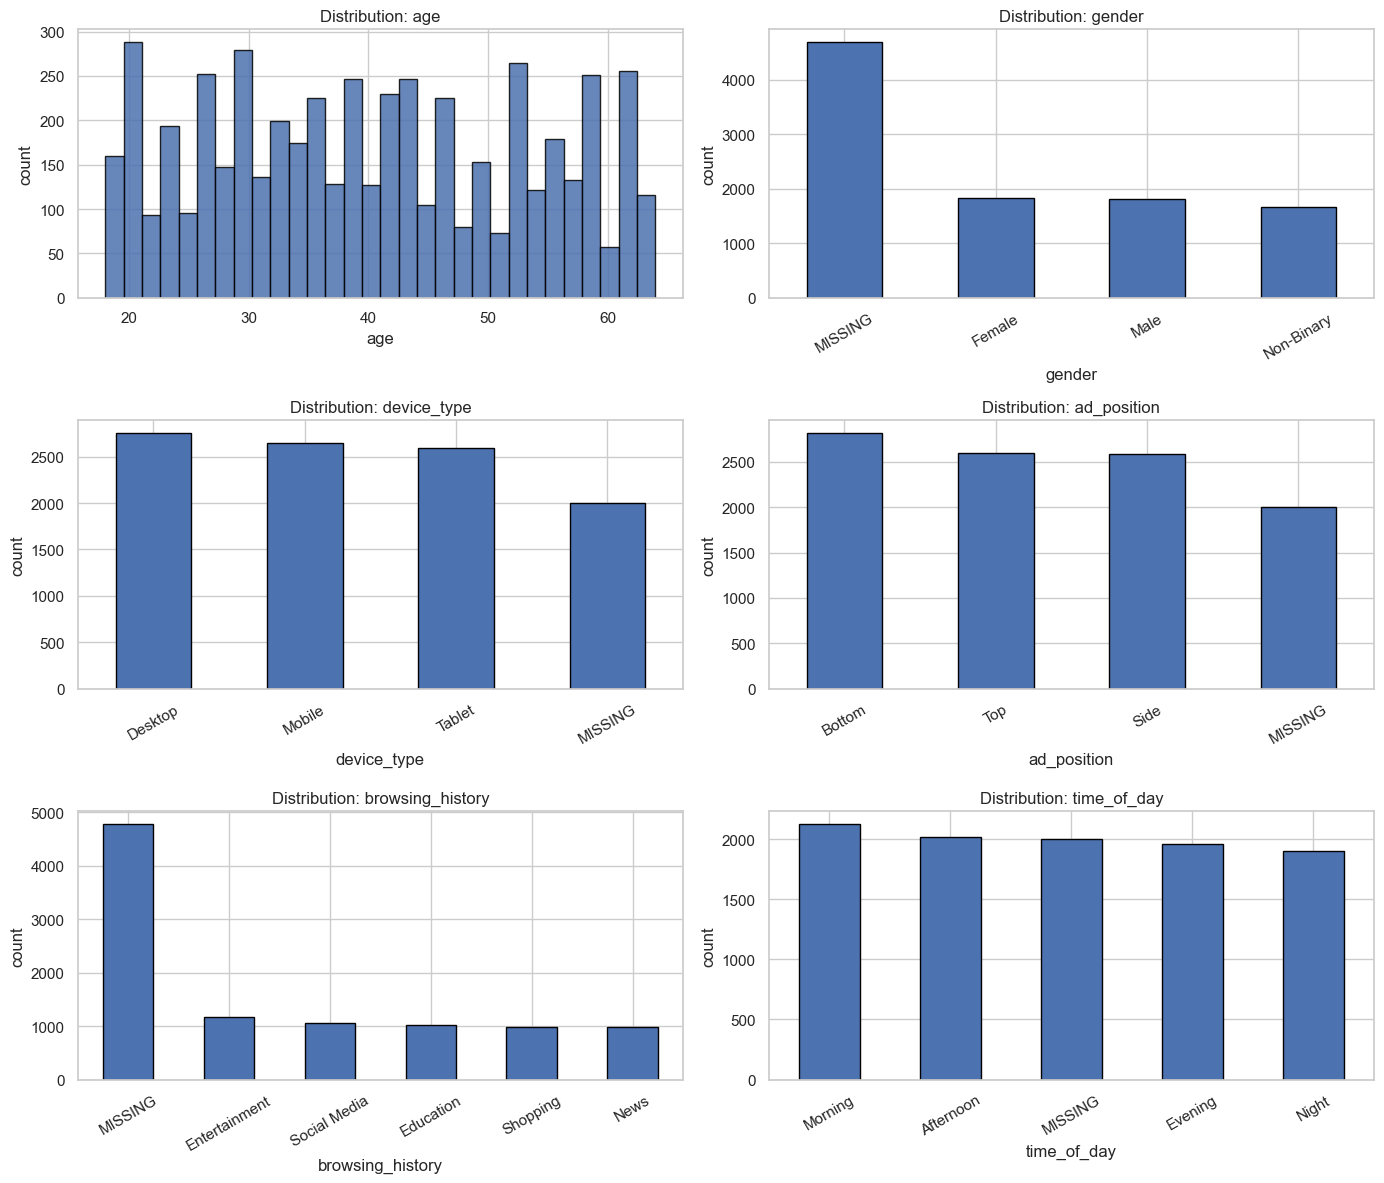

In [69]:
CANDIDATE_FEATURES = [
    "age", "gender", "device_type", "ad_position",
    "browsing_history", "time_of_day",
]

def plot_feature_distribution(data: pd.DataFrame, column: str, ax: plt.Axes) -> None:
    """Plot a single feature's distribution. Categoricals show NaN as a visible 'MISSING' bar."""
    if pd.api.types.is_numeric_dtype(data[column]):
        ax.hist(data[column].dropna(), bins=30, edgecolor="black", alpha=0.85)
    else:
        counts = data[column].fillna("MISSING").value_counts()
        counts.plot(kind="bar", ax=ax, edgecolor="black")
        ax.tick_params(axis="x", rotation=30)
    ax.set_title(f"Distribution: {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("count")

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, col in zip(axes.flat, CANDIDATE_FEATURES):
    plot_feature_distribution(df, col, ax)
plt.tight_layout()
plt.show()

### 3.7 CTR by feature value — pre-clustering signal check

Before any clustering, check whether each feature *alone* shows CTR variation across its values. A feature with near-zero CTR spread is noise for our purpose. A feature with wide CTR spread is signal — and is also a single-feature segmentation baseline that K-Means must beat.

**`MISSING` is included as its own category** because the *fact of missingness* may itself carry signal. If `MISSING` has a CTR materially different from the known categories, that argues for treating missingness as a category in encoding rather than imputing it away.

In [70]:
def ctr_by_category(data: pd.DataFrame, column: str, target: str = "click",
                    include_missing: bool = True) -> pd.DataFrame:
    """Per-category CTR, group size, and share of total rows."""
    series = data[column].fillna("MISSING") if include_missing else data[column]
    grouped = data.assign(**{column: series}).groupby(column, observed=True)[target]
    out = pd.DataFrame({
        "n_users":  grouped.size(),
        "n_clicks": grouped.sum(),
        "ctr":      grouped.mean(),
    })
    out["pct_of_total"] = out["n_users"] / len(data) * 100
    return out.sort_values("ctr", ascending=False)

def ctr_by_numeric_buckets(data: pd.DataFrame, column: str, bins: int = 5,
                            target: str = "click") -> pd.DataFrame:
    """Same as ctr_by_category but for a numeric column, quantile-bucketed."""
    series = pd.qcut(data[column], q=bins, duplicates="drop")
    return ctr_by_category(data.assign(**{column: series.astype(str)}),
                            column, target=target)

print(f"Overall CTR (baseline): {overall_ctr:.2%}\n")

for col in CANDIDATE_FEATURES:
    print(f"--- CTR by {col} ---")
    if pd.api.types.is_numeric_dtype(df[col]):
        summary = ctr_by_numeric_buckets(df, col, bins=5)
    else:
        summary = ctr_by_category(df, col)
    summary_display = summary.copy()
    summary_display["ctr"] = summary_display["ctr"].apply(lambda x: f"{x:.2%}")
    summary_display["pct_of_total"] = summary_display["pct_of_total"].round(2)
    print(summary_display.to_string())
    print("Std of ctr: ", summary_display["ctr"].str.replace("%", "").astype(float).std().round(2))
    print()

Overall CTR (baseline): 65.00%

--- CTR by age ---
                n_users  n_clicks     ctr  pct_of_total
age                                                    
(27.0, 35.0]       1013       711  70.19%         10.13
(35.0, 44.0]       1125       759  67.47%         11.25
MISSING            4766      3149  66.07%         47.66
(17.999, 27.0]     1083       707  65.28%         10.83
(44.0, 54.0]       1021       600  58.77%         10.21
(54.0, 64.0]        992       574  57.86%          9.92
Std of ctr:  4.92

--- CTR by gender ---
            n_users  n_clicks     ctr  pct_of_total
gender                                             
Male           1810      1191  65.80%         18.10
Female         1834      1206  65.76%         18.34
MISSING        4693      3051  65.01%         46.93
Non-Binary     1663      1052  63.26%         16.63
Std of ctr:  1.19

--- CTR by device_type ---
             n_users  n_clicks     ctr  pct_of_total
device_type                                      

### 3.8 Data quality summary

In [71]:
print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)
print(f"Rows                       : {len(df):,}")
print(f"Columns                    : {df.shape[1]}")
print(f"Duplicate rows             : {df.duplicated().sum()}")
print(f"Unique IDs                 : {df['id'].nunique():,}")
print(f"Overall CTR (baseline)     : {overall_ctr:.2%}")
print()
print("Missingness (%):")
for col, pct in (df.isnull().mean() * 100).sort_values(ascending=False).items():
    if pct > 0:
        print(f"  {col:20s} : {pct:5.2f}%")
print()
print("Columns excluded from feature matrix:")
print("  id, full_name   -> identifiers, not features")
print("  click           -> target / post-hoc evaluation only")
print()
print("Candidate clustering features:")
print(f"  {CANDIDATE_FEATURES}")

DATA QUALITY SUMMARY
Rows                       : 10,000
Columns                    : 9
Duplicate rows             : 2853
Unique IDs                 : 4,000
Overall CTR (baseline)     : 65.00%

Missingness (%):
  browsing_history     : 47.82%
  age                  : 47.66%
  gender               : 46.93%
  device_type          : 20.00%
  ad_position          : 20.00%
  time_of_day          : 20.00%

Columns excluded from feature matrix:
  id, full_name   -> identifiers, not features
  click           -> target / post-hoc evaluation only

Candidate clustering features:
  ['age', 'gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']


### 3.9 Dataset granularity check — one row = one ad impression, not one user

The 4,000 unique IDs across 10,000 rows means each user appears in the dataset **2.5 times on average**. Each row is a single ad impression, not a single user. Before deciding the preprocessing strategy, verify whether candidate features are **stable within a user** (user-level traits) or **vary per impression** (context features). If they're stable, we can collapse to one row per user with `drop_duplicates(subset=["id"])`. If they vary, we'd need an aggregation rule (mode/first/feature-engineered) — or have to discard impression-level features.

In [72]:
def users_with_multiple_values(data: pd.DataFrame, col: str) -> int:
    """Count users who have more than one distinct non-null value for `col` across their impressions."""
    per_user_nunique = data.dropna(subset=[col]).groupby("id")[col].nunique()
    return int((per_user_nunique > 1).sum())


print(f"{'Feature':<20s}  {'Users with >1 distinct value':>28s}")
print("-" * 50)
for col in CANDIDATE_FEATURES:
    count = users_with_multiple_values(df, col)
    print(f"  {col:<20s}: {count:>15,}")

Feature               Users with >1 distinct value
--------------------------------------------------
  age                 :               0
  gender              :               0
  device_type         :               0
  ad_position         :               0
  browsing_history    :               0
  time_of_day         :               0


**Result:** zero users have multiple distinct values for any candidate feature (NaN excluded). This means in *this* dataset, even nominally impression-level features like `time_of_day` and `ad_position` happen to be stable per user. We still drop them from the feature matrix because in a real ad system they would vary per impression and the production model shouldn't rely on a user-stable context assumption that wouldn't hold.

### 3.10 Click-value stability per user — required assumption for per-user CTR

Before collapsing to one row per user, verify the `click` column is also stable per user. If every user's `click` is identical across their impressions, then per-user CTR collapses to a single 0 or 1 — and `df_users["click"]` (first row after dedup) is numerically equivalent to `df.groupby("id")["click"].mean()`. If `click` *varies* within a user, per-user CTR becomes a fraction in `[0, 1]` and the dedup-first approach would silently throw away information.

In [73]:
clicks_per_user = df.groupby("id")["click"].nunique()
max_distinct_clicks = clicks_per_user.max()
users_with_mixed_clicks = (clicks_per_user > 1).sum()

print(f"Max distinct click values per user : {max_distinct_clicks}")
print(f"Users with mixed click outcomes    : {users_with_mixed_clicks:,}")

assert max_distinct_clicks == 1, (
    "Click value varies within at least one user. "
    "Per-user CTR cannot be collapsed to first-row-click. "
    "Switch to groupby('id')['click'].mean() and re-verify y construction below."
)
print("OK — click value is constant per user; first-row-click == per-user CTR.")

Max distinct click values per user : 1
Users with mixed click outcomes    : 0
OK — click value is constant per user; first-row-click == per-user CTR.


---

## 4. Preprocessing — Locked Decisions

Every decision below is grounded in a specific EDA finding from Section 3.

| Step | Decision | Why |
|---|---|---|
| Unit of analysis | One row per user (4,000 rows) | Problem statement frames this as **user** segmentation. EDA 3.9 confirmed candidate features are stable per user, so dedup is lossless. |
| Pure duplicate handling | `drop_duplicates(subset=["id"])` keeps first row per user | Demographics stable per user; first/mode/any are equivalent. |
| Index | `set_index("id")` so `X` and `y` share the same user-id index | Prevents the silent corruption where `X[i]` and `y[i]` describe different users after K-Means. |
| Drop columns | `id` (now the index), `full_name` (identifier), `time_of_day` + `ad_position` (impression-level, see 3.9), **`click`** (target — feeding it as a feature would be leakage) | Each removal traces to a specific category: ID, impression-context, or target. |
| Missing values in `age` | Median impute, plus an `is_age_missing` binary flag | Median preserves the bulk of the distribution; the flag retains the *fact* that the value was originally unknown, in case it correlates with cluster membership. |
| Missing values in categoricals | Fill with the string `"MISSING"` (treated as its own category in one-hot encoding) | EDA 3.7 showed MISSING-CTR ≈ overall CTR (MCAR-like). We use this strategy to **preserve all 4,000 users without fabricating values**, not because missingness is itself a signal. |
| Encoding | One-hot for `gender`, `device_type`, `browsing_history` | Categories have no natural order; target-encoding would risk leakage. |
| Scaling | `MinMaxScaler` on `age` only | **To match the [0, 1] range of the one-hot columns** so no single feature dominates Euclidean distance in K-Means. (Not because age is normally distributed — section 3.6 showed it isn't.) |
| Target `y` | Per-user CTR. Constant per user (verified in 3.10), so the first deduped row's `click` works directly. | |
| Final validation | Hard assertions: no leakage, no NaN, range `[0, 1]`, `X.index == y.index` | Each assertion guards a specific failure mode that would otherwise corrupt downstream cluster CTR silently. |

Final feature matrix `X` will have **16 columns** (1 numeric: `age`; 1 binary flag: `is_age_missing`; 14 one-hot columns: 4 gender + 4 device_type + 6 browsing_history) and **4,000 rows**, all values in `[0, 1]`.

### 4.1 Collapse to one row per user

`drop_duplicates(subset=["id"])` returns a view of `df`. Without `.copy()`. `set_index("id")` gives us a user-id index that we'll preserve through every transformation — this is what keeps `X` and `y` in lockstep all the way to K-Means.

In [74]:
df_users = df.drop_duplicates(subset=["id"]).set_index("id").copy()

print(f"Shape          : {df_users.shape}")
print(f"Unique users   : {df_users.index.nunique():,}")

Shape          : (4000, 8)
Unique users   : 4,000


### 4.2 Drop non-feature columns

Four columns leave the frame, each for a specific reason:

- **`full_name`** — pure identifier, zero predictive content.
- **`time_of_day`** — impression-level context (would vary per impression in real data; see 3.9).
- **`ad_position`** — same reason as `time_of_day`.
- **`click`** — **target / post-hoc evaluation only**. Including it in the feature matrix would be target leakage.

(`id` is no longer a column — it's the index after step 4.1, which is exactly what we want for downstream alignment.)

In [75]:
df_users = df_users.drop(columns=["full_name", "time_of_day", "ad_position", "click"])
print("Remaining columns:", list(df_users.columns))

Remaining columns: ['age', 'gender', 'device_type', 'browsing_history']


In [76]:
df_users.isna().sum()

age                 1867
gender              1876
device_type          782
browsing_history    1874
dtype: int64

### 4.3 Handle missing values

#### 4.3.1 Age — median impute with a missingness flag

Two operations, in this order, both required:

1. **Engineer `is_age_missing` *before* imputation.** Once we fillna, we can no longer recover which rows were originally null. The flag preserves that information as a binary feature, which K-Means can use to separate users with known vs unknown demographics if that distinction matters.
2. **Median impute using `df_users["age"].median()`.** Median is robust to skew and outliers (Section 3.6 showed `age` is not normally distributed). We use the **user-level** median (the 2,133 known ages among the 4,000 users), not the impression-level median over the original 10,000-row `df` — user-level data, user-level statistics.

The validation block below proves the flag is correctly aligned with NaN positions. This is exactly the kind of check that would have caught the misalignment if `is_age_missing` had been computed after `fillna`.

In [77]:
df_users["is_age_missing"] = df_users["age"].isna().astype(int)

# Validate is_age_missing
age_null_count    = df_users["age"].isna().sum()
flag_sum          = df_users["is_age_missing"].sum()
only_binary       = df_users["is_age_missing"].isin([0, 1]).all()
flag_1_where_null = (df_users.loc[df_users["age"].isna(),  "is_age_missing"] == 1).all()
flag_0_where_set  = (df_users.loc[df_users["age"].notna(), "is_age_missing"] == 0).all()

print(f"NaN count in age              : {age_null_count:,}")
print(f"Sum of is_age_missing (1s)    : {flag_sum:,}   {'OK' if flag_sum == age_null_count else 'MISMATCH'}")
print(f"Only 0/1 values               : {only_binary}")
print(f"Flag=1 wherever age is NaN    : {flag_1_where_null}")
print(f"Flag=0 wherever age is set    : {flag_0_where_set}")
print()
print("All checks passed!" if all([flag_sum == age_null_count, only_binary, flag_1_where_null, flag_0_where_set]) else "VALIDATION FAILED — check above.")

NaN count in age              : 1,867
Sum of is_age_missing (1s)    : 1,867   OK
Only 0/1 values               : True
Flag=1 wherever age is NaN    : True
Flag=0 wherever age is set    : True

All checks passed!


In [78]:
df_users["age"] = df_users["age"].fillna(df_users["age"].median())
df_users["age"].isna().sum()

np.int64(0)

#### 4.3.2 Categoricals — MISSING as its own category

For `gender`, `device_type`, `browsing_history` we fill NaN with the literal string `"MISSING"`. Two consequences:

1. **All 4,000 users are preserved** — none dropped because of incomplete demographics.
2. **`MISSING` becomes its own one-hot column** in step 4.4, so the *fact of being missing* is available to K-Means as a feature.

Important: EDA 3.7 showed MISSING-CTR is within ±1pp of the overall 65% CTR for every column. So missingness is **not itself a predictive signal**. We use this strategy for **row preservation** — it lets us avoid fabricating 47% of values in three columns — not because missingness predicts CTR.

In [79]:
df_users = df_users.fillna("MISSING")
df_users.isna().sum()

age                 0
gender              0
device_type         0
browsing_history    0
is_age_missing      0
dtype: int64

### 4.4 One-hot encode categoricals

`gender`, `device_type`, `browsing_history` have no natural ordering — ordinal encoding (`Male=0, Female=1, Non-Binary=2`) would invent a distance between categories that doesn't exist. One-hot is the methodologically clean choice. Target-aware encodings (target encoding, weight of evidence) are off the table because they would reintroduce a path for `click` to influence the feature matrix.

`dtype=float` makes the dummy columns `0.0` / `1.0` from the start, which keeps the final `X` uniformly float instead of a `bool`/`float` mix.

In [80]:
X = pd.get_dummies(df_users, columns=["gender", "device_type", "browsing_history"], dtype=float)
X.head()

,age,is_age_missing,gender_Female,gender_MISSING,gender_Male,gender_Non-Binary,device_type_Desktop,device_type_MISSING,device_type_Mobile,device_type_Tablet,browsing_history_Education,browsing_history_Entertainment,browsing_history_MISSING,browsing_history_News,browsing_history_Shopping,browsing_history_Social Media
id,,,,,,,,,,,,,,,,
670,22.0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3044,41.0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5912,41.0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5418,34.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9452,39.0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### 4.5 Scale `age` to `[0, 1]`

**Why MinMaxScaler and not StandardScaler:** K-Means uses Euclidean distance. The one-hot columns are in `{0, 1}` (range = 1). If we standardized `age` to mean 0, std 1, it would span roughly `[-2.5, +2.5]` — a 5× larger range — and would dominate every cluster boundary. MinMaxScaler puts `age` into `[0, 1]` to match the one-hot scale, so every feature contributes equal *maximum* distance.

This choice is about **scale matching for Euclidean K-Means**, not about whether `age` is normally distributed (Section 3.6 showed it isn't).

**Why scale only `age`:** every other column is already in `{0, 1}` (one-hot dummies + `is_age_missing`). Scaling them is an identity transform — pointless work that also makes the code falsely look like a more elaborate preprocessing step than it is. We touch `age` and leave the rest alone.

In [81]:
age_min, age_max = 0, 100
X["age"] = (X["age"] - age_min) / (age_max - age_min)
X.head()

,age,is_age_missing,gender_Female,gender_MISSING,gender_Male,gender_Non-Binary,device_type_Desktop,device_type_MISSING,device_type_Mobile,device_type_Tablet,browsing_history_Education,browsing_history_Entertainment,browsing_history_MISSING,browsing_history_News,browsing_history_Shopping,browsing_history_Social Media
id,,,,,,,,,,,,,,,,
670,0.22,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3044,0.41,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5912,0.41,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5418,0.34,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9452,0.39,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### 4.6 Build the post-hoc target `y` (per-user CTR), aligned to `X`

Per-user CTR is computed from the deduped frame and **reindexed to match `X.index`** (the order in which users appear after `drop_duplicates`, not the sorted-by-id order that `groupby` would default to). The `.loc[X.index]` step is what guarantees that `X.iloc[i]` and `y.iloc[i]` describe the same user.

Because we verified in 3.10 that every user has a single distinct `click` value, taking the click from the first deduped row is numerically equivalent to `df.groupby("id")["click"].mean()` — but it's faster, expresses the unit-of-analysis (user-level) clearly, and keeps the index aligned with `X`.

In [82]:
y = (
    df.drop_duplicates(subset=["id"])
      .set_index("id")["click"]
      .astype(float)
      .loc[X.index]
      .rename("per_user_ctr")
)
y.head()

id
670     1.0
3044    1.0
5912    1.0
5418    1.0
9452    0.0
Name: per_user_ctr, dtype: float64

### 4.7 Final validation — fail loud, not silent

Four assertions guard the four specific failure modes that would otherwise corrupt every downstream cluster CTR without throwing an error:

1. **`click` not in `X.columns`** — catches accidental target leakage if any future edit reintroduces the target as a feature.
2. **No NaN in `X`** — catches missing values that would crash K-Means or silently propagate as `nan` distances.
3. **All values in `[0, 1]`** — catches a scaling regression.
4. **`X.index.equals(y.index)`** — catches the most dangerous failure mode: position-based misalignment between `X` and `y` after any operation that resets the index. Without this assertion, every per-cluster CTR number in the final report would be the average of a randomly-shuffled subset of users.

If any assertion fires, **stop and fix**. Do not silence them.

In [83]:
assert "click" not in X.columns,                          "TARGET LEAKAGE: click is in X"
assert X.isna().sum().sum() == 0,                         "NaN present in X"
assert (X.values >= 0).all() and (X.values <= 1).all(),   "X values outside [0, 1]"
assert X.index.equals(y.index),                           "X / y index mismatch — would silently corrupt cluster CTR"

print("Preprocessing verification")
print("-" * 50)
print(f"X shape                    : {X.shape}")
print(f"y shape                    : {y.shape}")
print(f"X dtypes                   : {X.dtypes.unique().tolist()}")
print(f"X value range              : [{X.values.min():.4f}, {X.values.max():.4f}]")
print(f"'click' in X.columns       : {'click' in X.columns}")
print(f"NaN count in X             : {X.isna().sum().sum()}")
print(f"Index aligned (X vs y)     : {X.index.equals(y.index)}")
print()
print(f"Feature names ({len(X.columns)}):")
for name in X.columns:
    print(f"  - {name}")

Preprocessing verification
--------------------------------------------------
X shape                    : (4000, 16)
y shape                    : (4000,)
X dtypes                   : [dtype('float64'), dtype('int64')]
X value range              : [0.0000, 1.0000]
'click' in X.columns       : False
NaN count in X             : 0
Index aligned (X vs y)     : True

Feature names (16):
  - age
  - is_age_missing
  - gender_Female
  - gender_MISSING
  - gender_Male
  - gender_Non-Binary
  - device_type_Desktop
  - device_type_MISSING
  - device_type_Mobile
  - device_type_Tablet
  - browsing_history_Education
  - browsing_history_Entertainment
  - browsing_history_MISSING
  - browsing_history_News
  - browsing_history_Shopping
  - browsing_history_Social Media
